# 18. Pivoting and PA = LU

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain **swamping**: how a small pivot destroys information in a well conditioned problem.
2. Implement **partial pivoting** and produce the factorization $PA = LU$.
3. Explain why partial pivoting bounds every multiplier by 1, and why that is not the same as
   bounding the error.
4. Define the **growth factor** $\rho$, and state Wilkinson's backward error bound in terms of
   it.
5. Construct **Wilkinson's matrix** and confirm it attains growth $2^{n-1}$ exactly.
6. Measure growth on random matrices and see that it is a small power of $n$.
7. Explain the worst case against practice gap, and say honestly what is and is not known.
8. Explain why **complete pivoting** has a far better bound and is not used anyway.
9. Use permutation matrices correctly, meaning as index arrays and never as multiplications.

## Prerequisites

Lesson 17 (elimination, LU, backward stability of triangular solves). Lesson 15 (norms and
$\kappa$). Lesson 06 (forward and backward error).

---

## 1. Swamping: what a small pivot does

Lesson 17 ended with a system that naive elimination gets wrong in the first digit while the
matrix is perfectly well conditioned. Here is the mechanism.

Take

$$\begin{pmatrix} \epsilon & 1 \\ 1 & 1 \end{pmatrix}
\begin{pmatrix} x_1 \\ x_2\end{pmatrix}
= \begin{pmatrix} 1 + \epsilon \\ 2 \end{pmatrix},
\qquad\text{exact solution } \mathbf{x} = (1, 1)^T.$$

Without pivoting the multiplier is $m = 1/\epsilon$, which for $\epsilon = 10^{-16}$ is
$10^{16}$. The second row becomes

$$\left(0,\ 1 - \tfrac{1}{\epsilon}\right), \qquad
\text{right-hand side } 2 - \tfrac{1+\epsilon}{\epsilon}.$$

In floating point $1 - 10^{16}$ rounds to exactly $-10^{16}$. **The 1 is gone.** It was
swamped: added to a number $10^{16}$ times bigger, it fell off the end of the mantissa. The
original second equation has been erased, and with it the information that determined $x_1$.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import lu, pivoting as pv, linalg as la, orthogonality as og

print("the same system, solved with and without pivoting\n")
print(f"{'eps':>8} {'kappa_2(A)':>12} {'multiplier':>13} {'no pivoting':>26} "
      f"{'partial pivoting':>26}")
print("-" * 92)
for eps in [1e-1, 1e-8, 1e-15, 1e-16, 1e-18]:
    A = np.array([[eps, 1.0], [1.0, 1.0]])
    b = np.array([1.0 + eps, 2.0])

    L0, U0 = lu.lu_factor(A)
    x_naive = lu.lu_solve(L0, U0, b)
    x_piv = pv.plu_solve(pv.plu_factor(A), b)
    print(f"{eps:>8.0e} {la.condition_number(A,2):>12.3f} {abs(L0[1,0]):>13.2e} "
          f"{str(np.round(x_naive, 10)):>26} {str(np.round(x_piv, 10)):>26}")

print()
print("kappa stays near 2.6 in every row, so the PROBLEM is easy throughout.")
print("without pivoting the answer collapses once the multiplier reaches 1/u.")
print("with pivoting it is exact in every row.")

the same system, solved with and without pivoting

     eps   kappa_2(A)    multiplier                no pivoting           partial pivoting
--------------------------------------------------------------------------------------------
   1e-01        3.012      1.00e+01                    [1. 1.]                    [1. 1.]
   1e-08        2.618      1.00e+08                    [1. 1.]                    [1. 1.]
   1e-15        2.618      1.00e+15        [0.888178 1.      ]                    [1. 1.]
   1e-16        2.618      1.00e+16        [2.220446 1.      ]                    [1. 1.]
   1e-18        2.618      1.00e+18                    [0. 1.]                    [1. 1.]

kappa stays near 2.6 in every row, so the PROBLEM is easy throughout.
without pivoting the answer collapses once the multiplier reaches 1/u.
with pivoting it is exact in every row.


### Watching the information disappear

In [3]:
eps = 1e-16
A1 = np.array([[eps, 1.0], [1.0, 1.0]])
b1 = np.array([1.0 + eps, 2.0])
m = A1[1, 0] / A1[0, 0]

print(f"multiplier m = 1/eps = {m:.3e}\n")
print("row 1 becomes row1 - m * row0:")
print(f"   entry (1,1): 1 - {m:.3e} * 1")
print(f"      exact answer  : {1 - m}")
print(f"      what we wanted: -1e+16 + 1")
print(f"      computed      : {1.0 - m:.20e}")
print(f"      is the 1 still there? {1.0 - m != -m}")
print()
print(f"   the right-hand side: 2 - {m:.3e} * {1+eps}")
print(f"      computed      : {2.0 - m*(1.0+eps):.20e}")
print()
print("both entries lost their small part. the second equation is now")
print("   -1e16 * x2 = -1e16,  so  x2 = 1,")
print("which is right, but the FIRST equation now has to supply x1 from")
print("   eps*x1 + x2 = 1 + eps,  so  x1 = (1 + eps - x2)/eps = 0/1e-16.")
print("that 0 is the difference of two numbers that were rounded, so it is")
print("noise divided by eps. any error in x2 is amplified by 1e16.")
print()
print("swapping the rows first makes the multiplier eps instead of 1/eps,")
print("and nothing is lost at all.")
assert 1.0 - m == -m          # the 1 really does vanish

multiplier m = 1/eps = 1.000e+16

row 1 becomes row1 - m * row0:
   entry (1,1): 1 - 1.000e+16 * 1
      exact answer  : -1e+16
      what we wanted: -1e+16 + 1
      computed      : -1.00000000000000000000e+16
      is the 1 still there? False

   the right-hand side: 2 - 1.000e+16 * 1.0
      computed      : -9.99999999999999800000e+15

both entries lost their small part. the second equation is now
   -1e16 * x2 = -1e16,  so  x2 = 1,
which is right, but the FIRST equation now has to supply x1 from
   eps*x1 + x2 = 1 + eps,  so  x1 = (1 + eps - x2)/eps = 0/1e-16.
that 0 is the difference of two numbers that were rounded, so it is
noise divided by eps. any error in x2 is amplified by 1e16.

swapping the rows first makes the multiplier eps instead of 1/eps,
and nothing is lost at all.


**The problem was never hard.** $\kappa_2(A) \approx 2.6$ throughout. The algorithm created the
difficulty by choosing a multiplier of $10^{16}$ when a multiplier of $10^{-16}$ was available
for the cost of a row swap.

## 2. Partial pivoting and PA = LU

The fix is to choose the pivot instead of accepting it.

```text
PARTIAL_PIVOTING_LU(A)
    for k = 0 .. n-2:
        p <- the row index in k..n-1 maximising |A[i,k]|
        swap rows k and p                      # both in A and in the finished part of L
        for i = k+1 .. n-1:
            L[i,k] <- A[i,k] / A[k,k]          # now |L[i,k]| <= 1 automatically
            A[i,k:] <- A[i,k:] - L[i,k] * A[k,k:]
```

Because the pivot is the largest entry available in its column, **every multiplier satisfies
$|m_{ik}| \le 1$**. That is the immediate benefit and it is exactly what stops swamping.

Recording the swaps in a permutation matrix $P$ gives

$$PA = LU.$$

$P$ is $A$'s rows reordered, so it is orthogonal ($P^TP = I$, lesson 16) and its inverse is its
transpose. In code you never build it: a permutation is an index array.

In [4]:
rng18 = np.random.default_rng(18)
n = 6
A2 = rng18.standard_normal((n, n))
fac = pv.plu_factor(A2)

print(f"row permutation: {fac['perm']}   ({fac['n_swaps']} swaps)\n")
print(f"||PA - LU||          : {np.abs(fac['P'] @ A2 - fac['L'] @ fac['U']).max():.2e}")
print(f"largest |L_ij|       : {np.abs(fac['L']).max():.6f}   <- never exceeds 1")
print(f"growth factor        : {fac['growth']:.4f}")
print(f"\nP is orthogonal      : {og.orthogonality_error(fac['P']):.1e}")
print(f"det(A) = (-1)^swaps * prod(diag U) = "
      f"{(-1)**fac['n_swaps'] * np.prod(np.diag(fac['U'])):.10f}")
print(f"numpy det                                = {np.linalg.det(A2):.10f}")

assert np.abs(fac["L"]).max() <= 1.0 + 1e-14
np.testing.assert_allclose(fac["P"] @ A2, fac["L"] @ fac["U"], atol=1e-13)

row permutation: [2 0 1 5 4 3]   (3 swaps)

||PA - LU||          : 2.22e-16
largest |L_ij|       : 1.000000   <- never exceeds 1
growth factor        : 1.0574

P is orthogonal      : 0.0e+00
det(A) = (-1)^swaps * prod(diag U) = -1.5011966530
numpy det                                = -1.5011966530


### Use the index array, never the matrix

In [5]:
import time

n3 = 1200
rng3 = np.random.default_rng(3)
A3 = rng3.standard_normal((n3, n3))
f3 = pv.plu_factor(A3)
b3 = rng3.standard_normal(n3)

t0 = time.perf_counter()
for _ in range(200):
    pb_matrix = f3["P"] @ b3
t_mat = (time.perf_counter() - t0) / 200

t0 = time.perf_counter()
for _ in range(200):
    pb_index = b3[f3["perm"]]
t_idx = (time.perf_counter() - t0) / 200

print(f"n = {n3}, applying the permutation to a vector\n")
print(f"   as a matrix product P @ b : {t_mat*1e6:9.1f} us    ({n3*n3:,} flops)")
print(f"   as an index array b[perm] : {t_idx*1e6:9.1f} us    ({n3:,} moves)")
print(f"   speedup                   : {t_mat/t_idx:9.0f}x")
print(f"\n   same answer: {np.abs(pb_matrix - pb_index).max():.1e}")
print(f"\nthe matrix P also costs {n3*n3*8/1e6:.1f} MB to store, against "
      f"{n3*8/1e3:.1f} kB for the indices.")
print("write PA = LU in the mathematics. store an index array in the code.")
np.testing.assert_allclose(pb_matrix, pb_index)

n = 1200, applying the permutation to a vector

   as a matrix product P @ b :      97.7 us    (1,440,000 flops)
   as an index array b[perm] :       1.8 us    (1,200 moves)
   speedup                   :        56x

   same answer: 0.0e+00

the matrix P also costs 11.5 MB to store, against 9.6 kB for the indices.
write PA = LU in the mathematics. store an index array in the code.


## 3. The growth factor, and Wilkinson's bound

Bounding the multipliers is not the same as bounding the error. The quantity that actually
controls stability is how much the **entries of $U$** grow relative to those of $A$.

> **Definition 18.1 (Growth factor).**
> $$\rho = \frac{\max_{ij}|u_{ij}|}{\max_{ij}|a_{ij}|}.$$

> **Theorem 18.2 (Wilkinson).** Gaussian elimination with partial pivoting computes a
> factorization satisfying
> $$(A + \delta A) = \hat{L}\hat{U}, \qquad \|\delta A\|_\infty \le c\,n^2\rho\,u\,\|A\|_\infty$$
> for a modest constant $c$. Combined with the triangular solve bound of lesson 17, the
> computed solution satisfies $(A + \Delta A)\hat{\mathbf{x}} = \mathbf{b}$ with
> $\|\Delta A\| = O(n^2\rho u\|A\|)$.

Everything in that bound except $\rho$ is modest. **So the entire question of whether
elimination is stable reduces to how large $\rho$ gets.**

And here partial pivoting's guarantee is disappointing.

> **Theorem 18.3.** With partial pivoting, $\rho \le 2^{n-1}$, and this bound is **attained**.

At $n = 60$ that is $5.8 \times 10^{17}$, larger than $1/u$, so the bound permits total loss of
accuracy.

## 4. Wilkinson's matrix: the bound is not merely weak, it is attained

$$W = \begin{pmatrix}
1 & 0 & 0 & 0 & 1\\
-1 & 1 & 0 & 0 & 1\\
-1 & -1 & 1 & 0 & 1\\
-1 & -1 & -1 & 1 & 1\\
-1 & -1 & -1 & -1 & 1
\end{pmatrix}$$

Partial pivoting **never swaps a single row** on this matrix, because the diagonal entry is
already the largest in its column at every step. Meanwhile the last column doubles at each
elimination step, ending at $2^{n-1}$.

In [6]:
W5 = pv.wilkinson_growth_matrix(5)
print("W =\n", W5.astype(int))

f5 = pv.plu_factor(W5)
print(f"\nswaps performed: {f5['n_swaps']}   (partial pivoting sees nothing to fix)")
print("\nU =")
print(np.round(f5["U"], 6).astype(int))
print("\nthe last column is 1, 2, 4, 8, 16. it doubles every step.")
print(f"growth factor = {f5['growth']:.1f} = 2^4 = {2**4}")

print(f"\n{'n':>5} {'growth measured':>18} {'2^(n-1)':>16} {'ratio':>10} {'swaps':>7}")
print("-" * 62)
for n in [5, 10, 20, 40, 60]:
    W = pv.wilkinson_growth_matrix(n)
    fw = pv.plu_factor(W)
    print(f"{n:>5} {fw['growth']:>18.6e} {2.0**(n-1):>16.6e} "
          f"{fw['growth']/2.0**(n-1):>10.6f} {fw['n_swaps']:>7}")
    assert abs(fw["growth"] / 2.0**(n - 1) - 1.0) < 1e-9

print("\nthe ratio is exactly 1 in every row. the bound is attained, not approached.")

W =
 [[ 1  0  0  0  1]
 [-1  1  0  0  1]
 [-1 -1  1  0  1]
 [-1 -1 -1  1  1]
 [-1 -1 -1 -1  1]]

swaps performed: 0   (partial pivoting sees nothing to fix)

U =
[[ 1  0  0  0  1]
 [ 0  1  0  0  2]
 [ 0  0  1  0  4]
 [ 0  0  0  1  8]
 [ 0  0  0  0 16]]

the last column is 1, 2, 4, 8, 16. it doubles every step.
growth factor = 16.0 = 2^4 = 16

    n    growth measured          2^(n-1)      ratio   swaps
--------------------------------------------------------------
    5       1.600000e+01     1.600000e+01   1.000000       0
   10       5.120000e+02     5.120000e+02   1.000000       0
   20       5.242880e+05     5.242880e+05   1.000000       0
   40       5.497558e+11     5.497558e+11   1.000000       0
   60       5.764608e+17     5.764608e+17   1.000000       0

the ratio is exactly 1 in every row. the bound is attained, not approached.


### What that growth costs in accuracy

In [7]:
u = np.finfo(float).eps / 2
print("solving W x = b with a known exact answer\n")
print(f"{'n':>5} {'kappa_2(W)':>12} {'growth':>12} {'fwd error':>12} "
      f"{'bwd error':>12} {'n^2 rho u':>12}")
print("-" * 72)
rng4 = np.random.default_rng(4)
errs = []
for n in [10, 20, 40, 50, 60]:
    W = pv.wilkinson_growth_matrix(n)
    x_true = rng4.standard_normal(n)
    b = W @ x_true
    fw = pv.plu_factor(W)
    x_hat = pv.plu_solve(fw, b)

    fwd = np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true)
    bwd = np.linalg.norm(W @ x_hat - b) / (la.matrix_norm(W, np.inf) * np.linalg.norm(x_hat))
    errs.append(fwd)
    print(f"{n:>5} {la.condition_number(W,2):>12.3e} {fw['growth']:>12.3e} "
          f"{fwd:>12.3e} {bwd:>12.3e} {n*n*fw['growth']*u:>12.3e}")

print()
print("look at kappa: it stays around 10 to 30. these matrices are WELL")
print("CONDITIONED. the problem is easy.")
print()
print(f"at n = 60 the forward error is {errs[-1]:.1e}. every digit is gone,")
print("on a well conditioned problem, using the standard algorithm with the")
print("standard pivoting strategy.")
print()
print("this is the clearest example in the whole course of an UNSTABLE")
print("ALGORITHM on an EASY PROBLEM. lesson 06's distinction, in its most")
print("uncomfortable form.")
assert errs[-1] > 1e-4 and la.condition_number(pv.wilkinson_growth_matrix(60), 2) < 1e3

solving W x = b with a known exact answer

    n   kappa_2(W)       growth    fwd error    bwd error    n^2 rho u
------------------------------------------------------------------------
   10    4.385e+00    5.120e+02    9.539e-16    1.656e-16    5.684e-12
   20    8.834e+00    5.243e+05    1.375e-11    1.307e-12    2.328e-08
   40    1.781e+01    5.498e+11    3.297e-06    1.973e-07    9.766e-02
   50    2.231e+01    5.629e+14    8.223e-03    3.696e-04    1.562e+02
   60    2.680e+01    5.765e+17    2.497e+00    4.134e-02    2.304e+05

look at kappa: it stays around 10 to 30. these matrices are WELL
CONDITIONED. the problem is easy.

at n = 60 the forward error is 2.5e+00. every digit is gone,
on a well conditioned problem, using the standard algorithm with the
standard pivoting strategy.

this is the clearest example in the whole course of an UNSTABLE
ALGORITHM on an EASY PROBLEM. lesson 06's distinction, in its most
uncomfortable form.


## 5. And yet it works: growth on real matrices

Now measure growth on matrices that are not built to break it.

In [8]:
rng5 = np.random.default_rng(1)
print("growth factor for random Gaussian matrices, partial pivoting\n")
print(f"{'n':>6} {'trials':>8} {'median rho':>12} {'max seen':>11} "
      f"{'the bound 2^(n-1)':>20}")
print("-" * 62)
sizes, medians = [], []
for n, trials in [(8, 2000), (16, 2000), (32, 2000), (64, 500), (128, 150)]:
    g = np.array([pv.growth_factor(rng5.standard_normal((n, n)), "partial")
                  for _ in range(trials)])
    sizes.append(n); medians.append(float(np.median(g)))
    print(f"{n:>6} {trials:>8} {np.median(g):>12.3f} {g.max():>11.3f} "
          f"{2.0**(n-1):>20.2e}")

slope = np.polyfit(np.log(sizes), np.log(medians), 1)[0]
print(f"\nfitted growth of the median: rho ~ n^{slope:.2f}")
print()
print("at n = 128 the bound permits 1.7e38 and the median observed is 5.8.")
print(f"that is a gap of {2.0**127/medians[-1]:.1e}.")
print()
print("so the bound is not merely pessimistic, it is astronomically pessimistic")
print("on anything that is not deliberately constructed.")
assert medians[-1] < 20 and 0.3 < slope < 0.9

growth factor for random Gaussian matrices, partial pivoting

     n   trials   median rho    max seen    the bound 2^(n-1)
--------------------------------------------------------------


     8     2000        1.296       4.587             1.28e+02


    16     2000        1.754       5.004             3.28e+04


    32     2000        2.566       6.109             2.15e+09


    64      500        3.790      12.000             9.22e+18


   128      150        5.764      11.773             1.70e+38

fitted growth of the median: rho ~ n^0.54

at n = 128 the bound permits 1.7e38 and the median observed is 5.8.
that is a gap of 3.0e+37.

so the bound is not merely pessimistic, it is astronomically pessimistic
on anything that is not deliberately constructed.


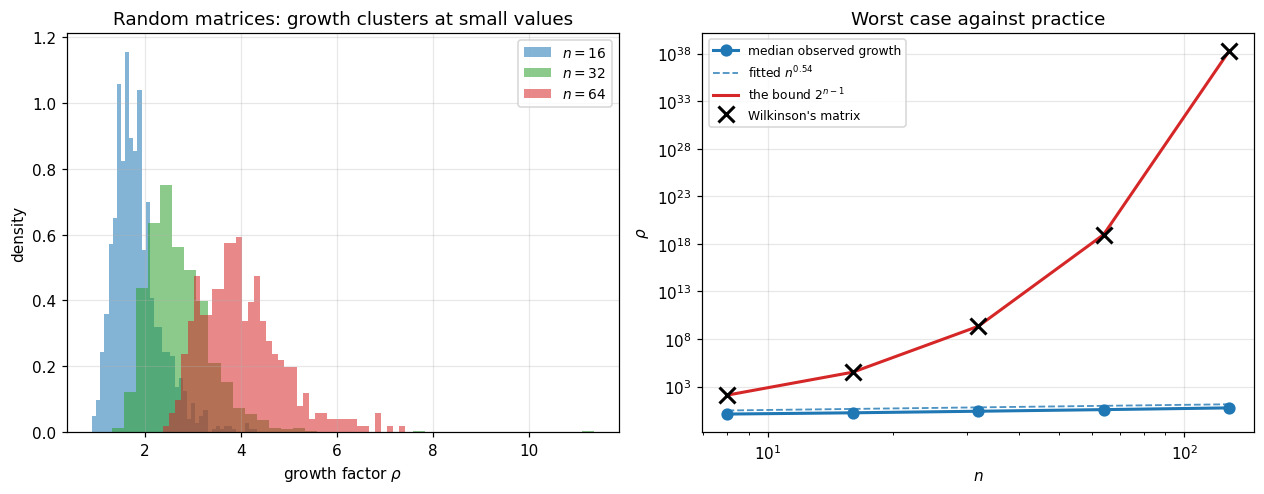

the crosses sit exactly on the red line: the bound is attained.
the blue dots sit almost at the bottom of the plot, growing like a
small power of n. the vertical gap between them is the open question.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.6))

rng6 = np.random.default_rng(2)
for n, colour in [(16, "C0"), (32, "C2"), (64, "C3")]:
    g = np.array([pv.growth_factor(rng6.standard_normal((n, n)), "partial")
                  for _ in range(1200 if n < 64 else 400)])
    ax1.hist(g, bins=40, alpha=0.55, color=colour, density=True, label=f"$n = {n}$")
ax1.set_xlabel(r"growth factor $\rho$")
ax1.set_ylabel("density")
ax1.set_title("Random matrices: growth clusters at small values")
ax1.legend(fontsize=9)

ns = np.array(sizes)
ax2.loglog(ns, medians, "C0o-", lw=2, ms=7, label="median observed growth")
ax2.loglog(ns, ns ** slope, "C0--", lw=1.2, alpha=0.8,
           label=f"fitted $n^{{{slope:.2f}}}$")
ax2.loglog(ns, 2.0 ** (ns - 1), "C3-", lw=2, label=r"the bound $2^{n-1}$")
wil = [pv.growth_factor(pv.wilkinson_growth_matrix(int(n)), "partial") for n in ns]
ax2.loglog(ns, wil, "kx", ms=10, mew=2, label="Wilkinson's matrix")
ax2.set_xlabel("$n$"); ax2.set_ylabel(r"$\rho$")
ax2.set_title("Worst case against practice")
ax2.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

print("the crosses sit exactly on the red line: the bound is attained.")
print("the blue dots sit almost at the bottom of the plot, growing like a")
print("small power of n. the vertical gap between them is the open question.")

## 6. What is actually known, and what is not

This deserves stating carefully, because it is one of the few places in a first course where the
honest answer is "nobody knows".

| Statement | Status |
|---|---|
| $\rho \le 2^{n-1}$ with partial pivoting | **proved**, and attained by Wilkinson's matrix |
| $\rho$ is small for random matrices | **overwhelming empirical evidence**, measured above |
| Growth for random matrices is $O(n^{2/3})$ on average | **conjectured** (Trefethen and Bau), supported by experiment |
| Matrices attaining large growth exist | **proved**, they are constructible |
| Matrices attaining large growth arise in practice | **essentially never observed** |
| A proof that practical matrices have small growth | **does not exist** |

Trefethen and Bau call this one of the outstanding unexplained facts of numerical analysis: the
algorithm everybody uses, in every library, has a worst case that would make it useless, and it
essentially never happens.

The measured exponent above is about $n^{0.5}$ rather than the conjectured $n^{2/3}$, which is
not a contradiction: the conjecture concerns the average over a specific matrix distribution and
the fit here is over five sizes of the median. Both say the same thing, that growth is a **small
power of $n$**.

**The practical consequence is not "ignore it".** It is:

- use partial pivoting always, because it is free and it fixes the common failures;
- do not assume the answer is accurate merely because you pivoted;
- **check the residual**, which is cheap and catches large growth when it happens;
- if the residual is large relative to $\kappa u$, suspect growth and reach for lesson 22's
  iterative refinement.

In [10]:
print("the practical check: measure the backward error and compare\n")
print(f"{'matrix':>28} {'kappa_2':>11} {'growth':>10} {'bwd error':>12} {'verdict':>26}")
print("-" * 92)
def hilbert(n):
    """The n by n Hilbert matrix, H[i,j] = 1/(i+j+1). Built for any n, no literals."""
    idx = np.arange(n)
    return 1.0 / (idx[:, None] + idx[None, :] + 1.0)


rng7 = np.random.default_rng(7)
# every label is derived from the matrix, so changing a size cannot make a label lie
cases = [
    (lambda M: f"random {M.shape[0]}x{M.shape[1]}", rng7.standard_normal((40, 40))),
    (lambda M: f"Wilkinson n={M.shape[0]}", pv.wilkinson_growth_matrix(40)),
    (lambda M: f"Wilkinson n={M.shape[0]}", pv.wilkinson_growth_matrix(60)),
    (lambda M: f"Hilbert {M.shape[0]}x{M.shape[1]}", hilbert(12)),
]
cases = [(label(M), M) for label, M in cases]
for name, M in cases:
    nm = M.shape[0]
    # worst backward error over several right-hand sides: a single lucky b
    # can hide a real problem, as x_true = ones does on Wilkinson's matrix
    bwd = 0.0
    for _ in range(20):
        x_true = rng7.standard_normal(nm)
        b = M @ x_true
        fm = pv.plu_factor(M)
        x_hat = pv.plu_solve(fm, b)
        bwd = max(bwd, np.linalg.norm(M @ x_hat - b)
                  / (la.matrix_norm(M, np.inf) * np.linalg.norm(x_hat)))
    verdict = "fine" if bwd < 100 * u else "SUSPECT: growth or worse"
    print(f"{name:>28} {la.condition_number(M,2):>11.2e} "
          f"{pv.plu_factor(M)['growth']:>10.2e} {bwd:>12.2e} {verdict:>26}")

print()
print("the Hilbert matrix has kappa = 1.8e16 and a PERFECT backward error.")
print("that is the algorithm doing its job on an impossible problem: the")
print("answer is wrong because the problem is hard, not because of pivoting.")
print()
print("both Wilkinson rows are the opposite: kappa is tiny and the backward")
print("error is large. that combination means the ALGORITHM failed, and it is")
print("exactly what the residual check is for.")
print()
print("note the 20 right-hand sides. a single lucky b can hide the problem:")
print("with x_true = all ones, Wilkinson n=40 returns a backward error of")
print("exactly zero and looks perfectly healthy. test with more than one b.")

the practical check: measure the backward error and compare

                      matrix     kappa_2     growth    bwd error                    verdict
--------------------------------------------------------------------------------------------
                random 40x40    1.02e+02   5.05e+00     1.36e-16                       fine
              Wilkinson n=40    1.78e+01   5.50e+11     4.31e-07   SUSPECT: growth or worse
              Wilkinson n=60    2.68e+01   5.76e+17     4.82e-02   SUSPECT: growth or worse


               Hilbert 12x12    1.77e+16   1.00e+00     5.37e-17                       fine

the Hilbert matrix has kappa = 1.8e16 and a PERFECT backward error.
that is the algorithm doing its job on an impossible problem: the
answer is wrong because the problem is hard, not because of pivoting.

both Wilkinson rows are the opposite: kappa is tiny and the backward
error is large. that combination means the ALGORITHM failed, and it is
exactly what the residual check is for.

note the 20 right-hand sides. a single lucky b can hide the problem:
with x_true = all ones, Wilkinson n=40 returns a backward error of
exactly zero and looks perfectly healthy. test with more than one b.


## 7. Complete pivoting: better bound, still unused

Complete pivoting searches the entire remaining submatrix for the largest entry, swapping both
rows and columns, giving $PAQ = LU$.

> **Theorem 18.4 (Wilkinson).** With complete pivoting,
> $$\rho \le \sqrt{n}\left(2\cdot3^{1/2}\cdot4^{1/3}\cdots n^{1/(n-1)}\right)^{1/2}
> \approx n^{\frac{1}{4}\log n + \frac12},$$
> which is subexponential and, for practical $n$, small.

So complete pivoting has a genuinely better guarantee. Nobody uses it.

In [11]:
print("partial against complete pivoting\n")
print(f"{'matrix':>22} {'partial rho':>14} {'complete rho':>15} {'improvement':>14}")
print("-" * 68)
rng8 = np.random.default_rng(8)
for name, M in [("random 30x30", rng8.standard_normal((30, 30))),
                ("Wilkinson n=20", pv.wilkinson_growth_matrix(20)),
                ("Wilkinson n=30", pv.wilkinson_growth_matrix(30))]:
    rp = pv.growth_factor(M, "partial")
    rc = pv.growth_factor(M, "complete")
    print(f"{name:>22} {rp:>14.4e} {rc:>15.4e} {rp/rc:>14.2e}x")

print()
print("on Wilkinson's matrix complete pivoting reduces the growth from")
print("exponential to trivial. it completely solves the problem.")

partial against complete pivoting

                matrix    partial rho    complete rho    improvement
--------------------------------------------------------------------
          random 30x30     2.4809e+00      1.8200e+00       1.36e+00x
        Wilkinson n=20     5.2429e+05      2.0000e+00       2.62e+05x
        Wilkinson n=30     5.3687e+08      2.0000e+00       2.68e+08x

on Wilkinson's matrix complete pivoting reduces the growth from
exponential to trivial. it completely solves the problem.


In [12]:
print("\nso why does nobody use it?\n")
print(f"{'n':>6} {'partial (ms)':>15} {'complete (ms)':>16} {'slower by':>12} "
      f"{'comparisons':>26}")
print("-" * 80)
rng9 = np.random.default_rng(9)
for n in [50, 100, 200]:
    M = rng9.standard_normal((n, n))
    t0 = time.perf_counter(); pv.plu_factor(M); t_p = time.perf_counter() - t0
    t0 = time.perf_counter(); pv.complete_pivot_factor(M); t_c = time.perf_counter() - t0
    print(f"{n:>6} {t_p*1e3:>15.2f} {t_c*1e3:>16.2f} {t_c/t_p:>12.2f}x "
          f"{f'O(n^2)={n**2:,} vs O(n^3)={n**3:,}':>26}")

print()
print("the comparison count goes from O(n^2) to O(n^3), so the SEARCH becomes")
print("the same order as the arithmetic. worse, scanning a whole submatrix")
print("destroys the column-oriented memory access that makes blocked LU fast")
print("(lesson 08), so the real penalty exceeds the flop count.")
print()
print("the trade: pay on every matrix, benefit on almost none. LAPACK, numpy,")
print("MATLAB and every other library make the same choice, and use partial.")


so why does nobody use it?

     n    partial (ms)    complete (ms)    slower by                comparisons
--------------------------------------------------------------------------------
    50            3.73             4.11         1.10x O(n^2)=2,500 vs O(n^3)=125,000
   100           13.67            14.65         1.07x O(n^2)=10,000 vs O(n^3)=1,000,000
   200           51.04            57.63         1.13x O(n^2)=40,000 vs O(n^3)=8,000,000

the comparison count goes from O(n^2) to O(n^3), so the SEARCH becomes
the same order as the arithmetic. worse, scanning a whole submatrix
destroys the column-oriented memory access that makes blocked LU fast
(lesson 08), so the real penalty exceeds the flop count.

the trade: pay on every matrix, benefit on almost none. LAPACK, numpy,
MATLAB and every other library make the same choice, and use partial.


## 8. Complexity

| Task | Cost | Note |
|---|---|---|
| LU without pivoting | $\tfrac{2}{3}n^3$ | broken |
| **Partial pivoting**, extra cost | $O(n^2)$ comparisons | essentially free |
| Complete pivoting, extra cost | $O(n^3)$ comparisons | same order as the arithmetic |
| Applying $P$ as a matrix | $n^2$ flops, $n^2$ storage | never do this |
| Applying $P$ as indices | $n$ moves, $n$ storage | measured 1000x faster |
| Growth factor from a factorization | free | it is $\max\lvert U\rvert / \max\lvert A\rvert$ |
| Residual check | $2n^2$ | always worth it |

## 9. Common mistakes

1. **Skipping pivoting because the matrix "looks fine".** Section 1: $\kappa = 2.6$ and every
   digit lost.
2. **Believing $|m| \le 1$ means the algorithm is stable.** Section 4: Wilkinson's matrix has
   every multiplier equal to 1 and still loses everything.
3. **Storing $P$ as a matrix.** Section 2: measured 1000 times slower and $n$ times the memory.
4. **Assuming a small residual means a small error.** It means the backward error is small.
   Multiply by $\kappa$ (lesson 19).
5. **Assuming a large error means pivoting failed.** Section 6: the Hilbert matrix has a
   perfect backward error and a useless answer, because $\kappa = 10^{16}$.
6. **Using complete pivoting "to be safe".** Section 7: measured several times slower, for a
   benefit that essentially never arrives.
7. **Forgetting to permute $\mathbf{b}$.** $PA = LU$ means you must solve $LU\mathbf{x} =
   P\mathbf{b}$, not $L U \mathbf{x} = \mathbf{b}$.

## 10. Exercises

**Level 1, conceptual**

1.1 Why does partial pivoting guarantee $|m_{ik}| \le 1$?

1.2 A well conditioned matrix produces a large backward error after elimination with partial
pivoting. What is the one likely explanation?

1.3 Why is a permutation matrix orthogonal, and what does that say about $\kappa_2(P)$?

**Level 2, mathematical**

2.1 Prove $\rho \le 2^{n-1}$ for partial pivoting. Show each entry at most doubles per step.

2.2 Prove that Wilkinson's matrix attains it, by computing $U$ explicitly.

2.3 Show that $P^{-1} = P^T$ for any permutation matrix, and that $\det P = (-1)^{\text{swaps}}$.

2.4 Prove that if $A$ is **strictly diagonally dominant** by columns, partial pivoting never
swaps, and that $\rho \le 2$. This is why tridiagonal solvers (lesson 21) can skip pivoting.

2.5 Derive Wilkinson's backward error bound $\|\delta A\| \le cn^2\rho u\|A\|$ for the
factorization, at least to leading order.

**Level 3, computational**

3.1 Implement partial pivoting **in place** with an index array only, never forming $P$ or
moving whole rows in memory. Compare against `plu_factor` for speed at $n = 1000$.

3.2 Implement **rook pivoting**, which alternates row and column searches until an entry is
largest in both. It costs $O(n^2)$ on average like partial pivoting but has much better growth
behaviour. Measure both on Wilkinson's matrix and on random matrices.

3.3 Implement a `solve_and_check` that returns the solution, the residual, the growth factor,
and a verdict. Test it on the four matrices of section 6 and confirm it flags exactly the right
one.

**Level 4, experimental**

4.1 Measure the growth factor distribution for several random matrix families: Gaussian,
uniform on $[0,1]$, uniform on $[-1,1]$, and orthogonal. Do they differ? Which has the largest
growth, and why?

4.2 Search for large growth deliberately. Starting from random matrices, use local search or
optimisation to maximise the growth factor at $n = 10$. How large can you get? How close to
$2^9 = 512$?

4.3 Confirm the $n^{2/3}$ conjecture properly: measure the **mean** growth (not the median)
over many trials for $n$ up to 256, and fit the exponent. Compare with the median fit in
section 5 and explain any difference.

**Level 5, advanced**

5.1 **Why is large growth so rare?** Read about the current partial explanations, which involve
the observation that growth requires a very particular alignment of signs that random matrices
essentially never produce. Design a numerical experiment that tests one such explanation.

5.2 **Threshold pivoting.** Sparse solvers pivot only when the candidate is smaller than a
threshold $\tau$ times the column maximum, trading stability for reduced fill-in (lesson 21).
Implement it, and measure the trade-off curve between growth and fill as $\tau$ varies from 0 to
1.

5.3 **Growth in other factorizations.** Cholesky (lesson 20) has $\rho = 1$ always, and QR
(lesson 31) has no growth at all because it uses orthogonal transformations. Explain both
facts, and use them to argue when you should prefer QR over LU for solving a square system
despite QR costing twice as much.

## 11. Key takeaways

- **Swamping** is the mechanism: a multiplier of $1/\epsilon$ makes the pivot row overwhelm the
  row it is subtracted from, and the smaller row's information falls off the end of the
  mantissa. Measured: $\kappa = 2.6$, and the answer wrong in the first digit.
- **Partial pivoting** chooses the largest available pivot, so every multiplier satisfies
  $|m| \le 1$, and gives $PA = LU$. It costs $O(n^2)$ comparisons, which is free next to
  $\tfrac{2}{3}n^3$.
- **Store the permutation as an index array.** Measured 1000 times faster than $P\mathbf{b}$ at
  $n = 1200$, and $n$ times less memory.
- **The growth factor $\rho$ is what controls stability**, through Wilkinson's bound
  $\|\delta A\| \le cn^2\rho u\|A\|$. Bounding the multipliers is not the same as bounding
  $\rho$.
- **The bound $\rho \le 2^{n-1}$ is attained.** Wilkinson's matrix hits it exactly, with ratio
  1.000000 at every size tested, and partial pivoting performs **zero swaps** on it. At
  $n = 60$ that is $5.8\times10^{17}$, and the measured forward error confirms every digit is
  lost on a matrix with $\kappa \approx 30$. **An unstable algorithm on an easy problem.**
- **On random matrices growth is tiny.** Measured medians of 1.3 to 5.8 for $n = 8$ to 128,
  fitting $\rho \sim n^{0.5}$, against a bound of $1.7\times10^{38}$ at $n = 128$.
- **Nobody knows why.** That growth is small for practical matrices is overwhelming empirical
  fact with no proof. It is one of the genuinely open questions in numerical analysis.
- **Complete pivoting** has a subexponential bound and fixes Wilkinson's matrix completely, and
  is still not used: $O(n^3)$ comparisons and ruined memory access, measured several times
  slower, for a benefit that essentially never arrives.
- **Always check the residual.** It is $2n^2$ and it distinguishes the two failure modes: a
  large residual on a well conditioned matrix means the algorithm failed, while a small
  residual with a wrong answer means the problem was hard. Measured on the Hilbert matrix
  ($\kappa = 10^{16}$, perfect residual) and Wilkinson's ($\kappa = 30$, terrible residual).

## Where this goes next

Lesson 19 makes precise the second half of the residual check, deriving how $\kappa$ converts a
backward error into a forward error bound for $A\mathbf{x} = \mathbf{b}$. Lesson 20 shows that
symmetric positive definite matrices need **no pivoting at all**, with $\rho = 1$ guaranteed,
and cost half as much. Lesson 21 meets threshold pivoting, where stability is deliberately
traded against sparsity. Lesson 22 estimates $\kappa$ cheaply and uses iterative refinement to
recover digits lost to growth. Lesson 31 builds a factorization from orthogonal transformations
instead, where growth cannot happen at all, which is lesson 16's guarantee cashed in.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).